In [1]:
import warnings
import numpy as np
import scipy as sp
%matplotlib inline
import matplotlib.pyplot as plt
import tanglepack
import tanglepack.InitialManifold
from scipy.optimize import newton as newton_method

%load_ext autoreload
%autoreload 2

/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [16]:
def henon(point):
    """defines the henon map for classical parameters to test basic functionality"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([y - k + x ** 2, -b * x])


def henon_inverse(point):
    """defines the inverse henon map for classical parameters"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y ** 2) / (b ** 2)])


def henon_jacobian(point):
    """defines the jacobian for the henon map"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([[2*x, 1], [-b, 0]])

In [17]:
point = tanglepack.FixedPoint(henon, [4, -4], henon_inverse, henon_jacobian)
fixed_point = point.fixed_point[0]
print(fixed_point)

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
[ 4.31662458 -4.31662318]


In [18]:
jacobian = henon_jacobian(fixed_point)

eigenvalues, eigenvectors = np.linalg.eig(jacobian)

print(f"eigenvectors: {eigenvectors}")

t_values = np.linspace(0, 1e-2, 100)

line1 = np.array([fixed_point + t * eigenvectors[:, 0] for t in t_values])

line2 = np.array([fixed_point + t * eigenvectors[:, 1] for t in t_values])


iterated_line1 = np.array(list(map(henon, line1)))

iterated_line2 = np.array(list(map(henon, line2)))

eigenvectors: [[ 0.99317577 -0.11662714]
 [-0.11662714  0.99317577]]


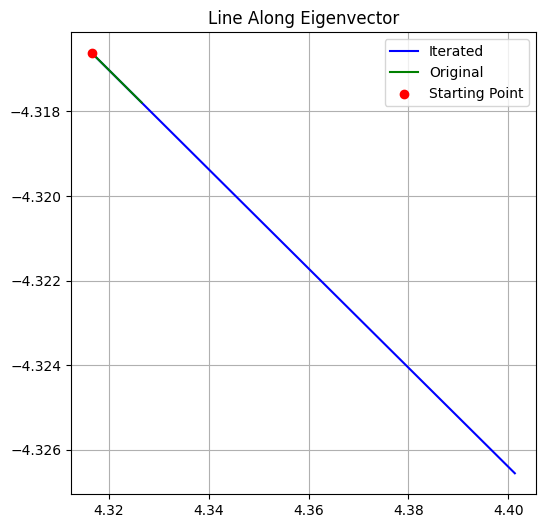

In [19]:
X, Y = iterated_line1[:, 0], iterated_line1[:, 1]

# Plot
plt.figure(figsize=(6,6))
plt.plot(X, Y, 'b-', label="Iterated")  # Line

X, Y = line1[:, 0], line1[:, 1]
plt.plot(X, Y, 'g-', label="Original")  # Line

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='red', zorder=3, label="Starting Point")  # Mark the start point
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()

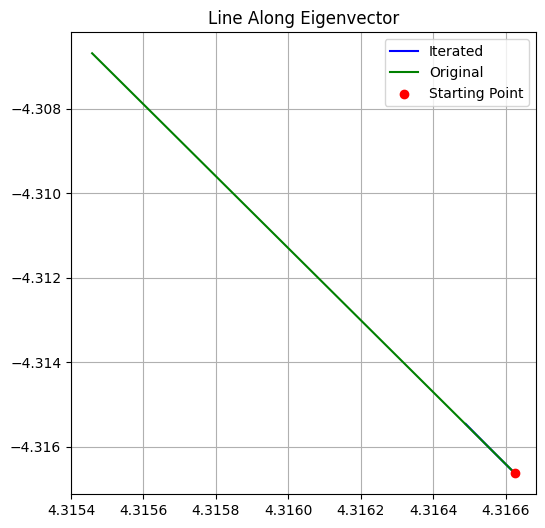

In [20]:
X, Y = iterated_line2[:, 0], iterated_line2[:, 1]

# Plot
plt.figure(figsize=(6,6))
plt.plot(X, Y, 'b-', label="Iterated")  # Line

X, Y = line2[:, 0], line2[:, 1]
plt.plot(X, Y, 'g-', label="Original")  # Line

plt.scatter(fixed_point[0], fixed_point[1], color='red', zorder=3, label="Starting Point")  # Mark the start point
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()